Install the Libraries Required

In [1]:
%pip install requests numpy matplotlib scipy scikit-learn torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import numpy as np
import requests

Helper Functions to Read Fiels

In [ ]:
#from past labs in EECS4643
def readBiopacResults(filename):
    with open(filename, 'r') as f:
        temp = [l for l in f]
    result = []
    for i in range(0, len(temp)):
        q = temp[i].strip().split()
        if q:
            result.append([float(v) for v in q])

    return np.array(result)

In [4]:
def readCSV(filename):
    """
    Read a CSV file (with a single header row) into a numeric NumPy array.

    Expected format
    - First line: column headers (skipped)
    - Remaining lines: comma-separated numeric values per row

    Returns
    - np.ndarray of shape (num_rows, num_columns)
    """
    with open(filename, 'r') as f:
        temp = [l for l in f]

    result = []
    for i in range(0, len(temp)):
        # Skip header row
        if i == 0:
            continue
        q = temp[i].strip().split(',')
        if q:
            result.append([float(val) for val in q])

    return np.array(result)

Load a public data set with ECG data

In [5]:
# Download a public ECG sample and load it as our working dataset
# - Source: NeuroKit demo ECG sampled at 1000 Hz
# - We save it locally as CSV and then parse it into a numeric array
# - Variable `fs` holds the sampling rate (Hz); downstream code relies on it

url = 'https://raw.githubusercontent.com/neuropsychology/NeuroKit/master/data/ecg_1000hz.csv'
local_filename = 'sample_ecg_data.csv'
fs = 1000  # samples per second (Hz)

# Fetch and store the CSV file
response = requests.get(url)
with open(local_filename, 'wb') as f:
    f.write(response.content)

# Load the CSV as a numeric array (skips header, parses comma-separated values)
try:
    data = readCSV(local_filename)
    print(f'Data Shape: {data.shape}')
except Exception as e:
    print(f'Error reading file: {e}')

Data Shape: (50000, 1)


Pre-Process EEG data

In [ ]:
def bandpass_filter(data, lowcut, highcut, fs, order=5):
    """
    Apply a zero-phase band-pass filter to emphasize the QRS energy band.

    Parameters
    - data: 1D array of ECG samples
    - lowcut/highcut: passband edges in Hz (typical QRS band ~5–15 Hz)
    - fs: sampling rate in Hz
    - order: Butterworth filter order
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    #Handle not Enough data issue
    padlen = 3 * (max(len(a), len(b)) - 1)
    if data.size <= padlen:
        return data

    y = filtfilt(b, a, data)
    return y


def preprocess_data(raw_data, fs):
    """
    Standardize an ECG channel for analysis.

    Steps
    1) Ensure a 1D float array
    2) Band-pass filter (~5–15 Hz)
    3) normalization: center at 0, unit variance
    Returns
    - 1D NumPy array (float) normalized and ready for peak detection or modeling
    """
    # Ensure 1D float array
    x = np.asarray(raw_data)
    if x.ndim > 1:
        x = x[:, 0]
    x = x.astype(float)

    # Band-pass filter
    lowcut = 5
    highcut = 15.0
    filtered = bandpass_filter(x, lowcut, highcut, fs, order=2)
    #normalize
    std = np.std(filtered)
    normalized = (filtered - np.mean(filtered)) / std
    return normalized

Plot a result

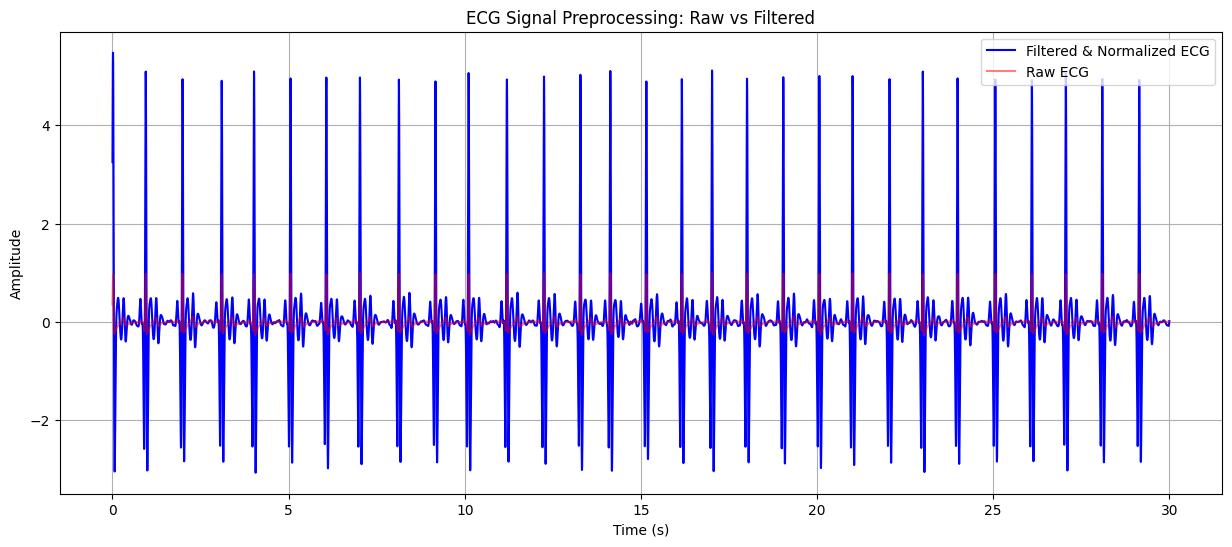

Preprocessing complete: Band-pass (5–15 Hz) and Z-score normalization applied.


In [57]:
# Visual check: compare raw ECG vs. preprocessed ECG
# - Gray trace: unfiltered raw signal
# - Blue trace: band‑passed and z‑scored signal used for detection
# - We limit the view to `time_toDisplay` seconds for readability

ecg_raw = data[:, 0]
ecg_normalized = preprocess_data(ecg_raw, fs)

time = np.arange(len(ecg_raw)) / fs
time_toDisplay = 30  # seconds to plot

plt.figure(figsize=(15, 6))
plt.plot(time[: time_toDisplay * fs], ecg_normalized[: time_toDisplay * fs],
         label='Filtered & Normalized ECG', color='blue')

plt.plot(time[: time_toDisplay * fs], ecg_raw[: time_toDisplay * fs],
         label='Raw ECG', alpha=0.5, color='red')
plt.title('ECG Signal Preprocessing: Raw vs Filtered')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

print('Preprocessing complete: Band-pass (5–15 Hz) and Z-score normalization applied.')

Label the Data set

In [45]:
# Peak-only labeling (Ground Truth Creation)
# --------------------------------------------------------------
# Goal: Mark the locations of peaks  on ECG
#   y[i] == 1 indicates a detected peak at sample i and 0 otherwise.
# Outputs
# - `X`: the normalized ECG signal (1D array)
# - `y`: the binary per-sample label vector (1D array)

min_rr_sec = 0.6  #sec  minimum RR interval to avoid double counting (seconds)
# Detect peaks on the normalized signal to avoid repeat detections
peaks, _ = find_peaks(ecg_normalized, distance=min_rr_sec*fs)

# Create a binary label vector aligned with the full signal
labels_vector = np.zeros(ecg_normalized.shape[0], dtype=int)
labels_vector[peaks] = 1

# Feature (X) and label (y) for downstream use
X = ecg_normalized
y = labels_vector

Display Training label tests

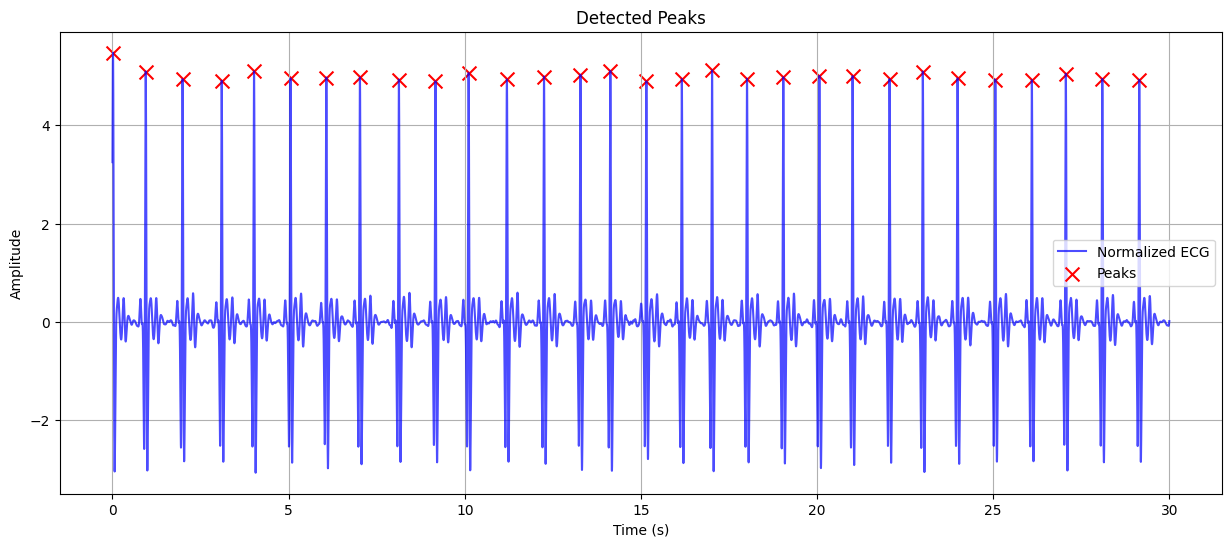

In [44]:
# Visualize detected peaks on the normalized ECG (sanity check)
# ----------------------------------------------------------------
# This plot helps confirm that the automatic peak detector is finding
# reasonable R-peaks at the right times

duration = 30 #plot first X seconds
max_index = duration * fs

# 4) Plot ECG and overlay detected peaks
plt.figure(figsize=(15, 6))
plt.plot(time[:max_index], ecg_normalized[:max_index], label='Normalized ECG', color='blue', alpha=0.7)
plt.scatter(time[peaks[peaks < max_index]], ecg_normalized[peaks[peaks < max_index]], color='red', marker='x', s=100, label='Peaks')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Detected Peaks')
plt.legend()
plt.grid()
plt.show()


Verified Training labelling is good, train 1D CNN model.

In [ ]:
# Sequence labeling model (1D CNN) for per-sample QRS detection
# ----------------------------------------------------------------
# Objective
# Train a simple convolutional network that takes the entire ECG segment and
# predicts, for each sample, whether it belongs to an R-peak (1) or not (0).
#
# Design choices
# - Train/validation split is performed by time (80/20) to respect temporal order.
# - Convolution-only to make this easy
# - Since Peaks is <<< nonpeaks use BCEWithLogitsLoss, to weight the "positives" with high value 999

#References: https://medium.com/@zergtant/use-weighted-loss-function-to-solve-imbalanced-data-classification-problems-749237f38b75
#References: https://www.codegenes.net/blog/examplebcewithlogitsloss-pytorch/
#References: https://colab.research.google.com/github/ancilcleetus/Time_Series_Project_01_HeartBeatInsight/blob/main/notebooks/Deep_Learning_Methods_for_ECG_Heartbeat_Classification.ipynb


import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score

# 1) Train/Val split by time (80/20)
split_idx = int(0.8 *  X.shape[0]) #80% of data set is for training, rest for val.
X_train_np, y_train_np = X[:split_idx], y[:split_idx]
X_val_np,   y_val_np   = X[split_idx:], y[split_idx:]

# 2) Convert to tensors  (unsqueeze since pytorch kept complaining) to have BATCH_size, channels, Length.
X_train_t = torch.tensor(X_train_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
y_train_t = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
X_val_t   = torch.tensor(X_val_np,   dtype=torch.float32).unsqueeze(0).unsqueeze(0)
y_val_t   = torch.tensor(y_val_np,   dtype=torch.float32).unsqueeze(0).unsqueeze(0)



pos = float(y_train_np.sum())
neg = float(len(y_train_np) - pos)
print("Number of Peaks: ", pos)
print("Number of Non-Peaks",neg)
class SimpleNet(nn.Module):
    """A compact 1D CNN
    Architecture
    - 1 -> 32 -> 64 -(Dropout)->1x1 conv
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=7, padding=3), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Conv1d(64, 1, kernel_size=1)  # logits per time sample
        )
    def forward(self, x):  #since it is a simple sequential net.. just return the output
        return self.net(x) 


model = SimpleNet()
## Make the weight of positives super high.
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(999))
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 4) Training loop (full sequence per batch)
train_acc_history, val_acc_history = [], []
train_loss_history, val_loss_history = [], []
epochs = 125

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    logits_train = model(X_train_t)  # (1,1,T_train)
    loss = criterion(logits_train, y_train_t)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        preds_train = (logits_train.sigmoid() >= 0.5).cpu().numpy().astype(int).reshape(-1)
        train_acc = accuracy_score(y_train_np, preds_train)

    model.eval()
    with torch.no_grad():
        logits_val = model(X_val_t)
        val_loss = criterion(logits_val, y_val_t).item()
        preds_val = (logits_val.sigmoid() >= 0.5).cpu().numpy().astype(int).reshape(-1)
        val_acc = accuracy_score(y_val_np, preds_val)

    train_loss_history.append(loss.item())
    val_loss_history.append(val_loss)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f'Epoch {epoch+1:02d}/{epochs} — loss: {loss.item():.4f}  acc: {train_acc:.4f}  val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}')

# 5) Final accuracy on the validation timeline (per-sample)
y_pred = preds_val  # carried forward for evaluation cell
print(f'\nValidation Accuracy: {val_acc:.4f} (per-sample)')

Number of Peaks:  40.0
Number of Non-Peaks 39960.0
Epoch 01/125 — loss: 1.2719  acc: 0.7257  val_loss: 1.0690  val_acc: 0.5964
Epoch 02/125 — loss: 1.0725  acc: 0.5070  val_loss: 0.9764  val_acc: 0.5591
Epoch 03/125 — loss: 0.9984  acc: 0.4115  val_loss: 0.9247  val_acc: 0.5288
Epoch 04/125 — loss: 0.9261  acc: 0.3987  val_loss: 0.8939  val_acc: 0.5705
Epoch 05/125 — loss: 0.8907  acc: 0.4554  val_loss: 0.8717  val_acc: 0.6064
Epoch 06/125 — loss: 0.8771  acc: 0.5337  val_loss: 0.8538  val_acc: 0.6389
Epoch 07/125 — loss: 0.8530  acc: 0.5916  val_loss: 0.8396  val_acc: 0.6682
Epoch 08/125 — loss: 0.8368  acc: 0.6407  val_loss: 0.8273  val_acc: 0.6970
Epoch 09/125 — loss: 0.8241  acc: 0.6817  val_loss: 0.8164  val_acc: 0.7472
Epoch 10/125 — loss: 0.8275  acc: 0.7167  val_loss: 0.8059  val_acc: 0.7744
Epoch 11/125 — loss: 0.8170  acc: 0.7457  val_loss: 0.7962  val_acc: 0.7799
Epoch 12/125 — loss: 0.7926  acc: 0.7650  val_loss: 0.7877  val_acc: 0.7866
Epoch 13/125 — loss: 0.7958  acc: 0.7

Test Model on validation dataset.

--- Per-sample Confusion Matrix ---
[[9615  375]
 [   0   10]]

--- Per-sample Classification Report ---
              precision    recall  f1-score   support

 Non-Complex       1.00      0.96      0.98      9990
     Complex       0.03      1.00      0.05        10

    accuracy                           0.96     10000
   macro avg       0.51      0.98      0.52     10000
weighted avg       1.00      0.96      0.98     10000



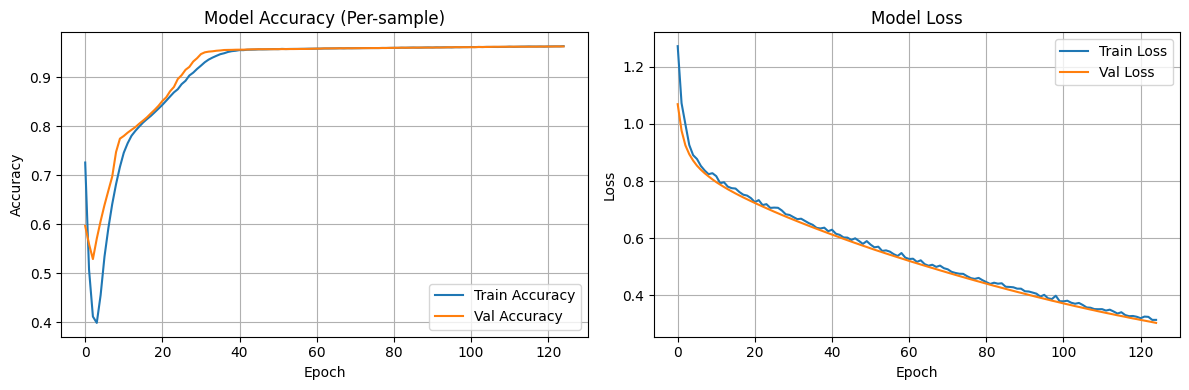

In [34]:
# Validation and Visualization
# ---------------------------

from sklearn.metrics import confusion_matrix, classification_report


# 1) Per-sample validation (sequence labeling)
cm = confusion_matrix(y_val_np, y_pred)
tn, fp, fn, tp = cm.ravel()
print("--- Per-sample Confusion Matrix ---")
print(cm)
print("\n--- Per-sample Classification Report ---")
print(classification_report(y_val_np, y_pred, target_names=['Non-Complex', 'Complex']))


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_acc_history, label='Train Accuracy')
plt.plot(val_acc_history,   label='Val Accuracy')
plt.title('Model Accuracy (Per-sample)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history,   label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()


Define Method to lerage trained model on new data

In [52]:
def predict_complexes(raw_data_array, sampling_rate, min_rr_sec=0.6, proba_threshold=0.5):
    """
    Detect R-peaks using the trained sequence model (1D CNN).

    Pipeline
    1) Preprocess input (band-pass + z-score) at its native sampling rate.
    2) If needed, resample the preprocessed signal to the model's training rate (`fs`).
    3) Run the CNN to obtain a probability per sample (after sigmoid).
    4) Peak-pick the probability sequence with a physiological minimum RR interval.
    5) Map detected peak indices back to the ORIGINAL signal's index space if resampled.

    Parameters
    - raw_data_array (1D array): ECG samples to analyze.
    - sampling_rate (int): Sampling rate (Hz) of `raw_data_array`.
    - min_rr_sec (float): Minimum RR interval in seconds between consecutive beats.
    - proba_threshold (float): Minimum probability required to accept a peak.

    Returns
    - np.ndarray: Detected peak indices in the ORIGINAL input index space.

    Notes
    - Requires a trained `model` (ECGSequenceCNN) and a valid `fs` (training rate)
      to be present in the notebook state. If missing, raise an informative error.
    """
    # Guards: model and training fs must exist
    if 'model' not in globals():
        raise RuntimeError('Trained model not found. Please run the training cell before calling predict_complexes.')
    if 'fs' not in globals():
        raise RuntimeError('Training sampling rate `fs` not found. Ensure the dataset load cell defining `fs` has run.')

    # 1) Preprocess at native sampling rate
    sig_native = preprocess_data(raw_data_array, sampling_rate)

    # 2) Resample to training rate if needed (so the CNN sees familiar scale)
    fs_train = int(fs)
    if int(sampling_rate) != fs_train:
        from scipy.signal import resample_poly
        from math import gcd
        g = gcd(fs_train, int(sampling_rate))
        up = fs_train // g
        down = int(sampling_rate) // g
        sig_model = resample_poly(sig_native, up=up, down=down)
        scale_to_orig = sampling_rate / fs_train
    else:
        sig_model = sig_native
        scale_to_orig = 1.0

    # 3) Run the CNN to get per-sample probabilities
    import torch
    model.eval()
    x_t = torch.tensor(sig_model, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1,1,T)
    device = next(model.parameters()).device
    with torch.no_grad():
        proba = model(x_t.to(device)).sigmoid().cpu().numpy().reshape(-1)

    # 4) Peak picking on probability sequence
    distance_samples = int(min_rr_sec * fs_train)  # apply RR at model rate
    pred_rel, props = find_peaks(proba, distance=distance_samples, height=proba_threshold)

    # 5) Map indices back to original signal index space if resampled
    pred_abs = np.clip(np.round(pred_rel * scale_to_orig).astype(int), 0, len(raw_data_array) - 1)
    return pred_abs

Call the model prediction interface

In [53]:
lab3_Results = readBiopacResults('./Lab-03-L05_ayesha.txt')
sample_rate = 800
lab3_results_size = lab3_Results.shape[0] / sample_rate
lab3_Results=lab3_Results[:, 0]
print(f'Duration (s): {lab3_results_size:.2f}')

detected_indices = predict_complexes(lab3_Results, sample_rate)

print('Test completed.')
print(f'Detected {len(detected_indices)} peaks in the test segment.')
if len(detected_indices) > 0:
    print(f'First 10 detected indices: {detected_indices[:10]}')

Duration (s): 163.70
Test completed.
Detected 179 peaks in the test segment.
First 10 detected indices: [ 411 1148 1924 2708 3462 4243 5054 5831 6595 7385]


Plot the output

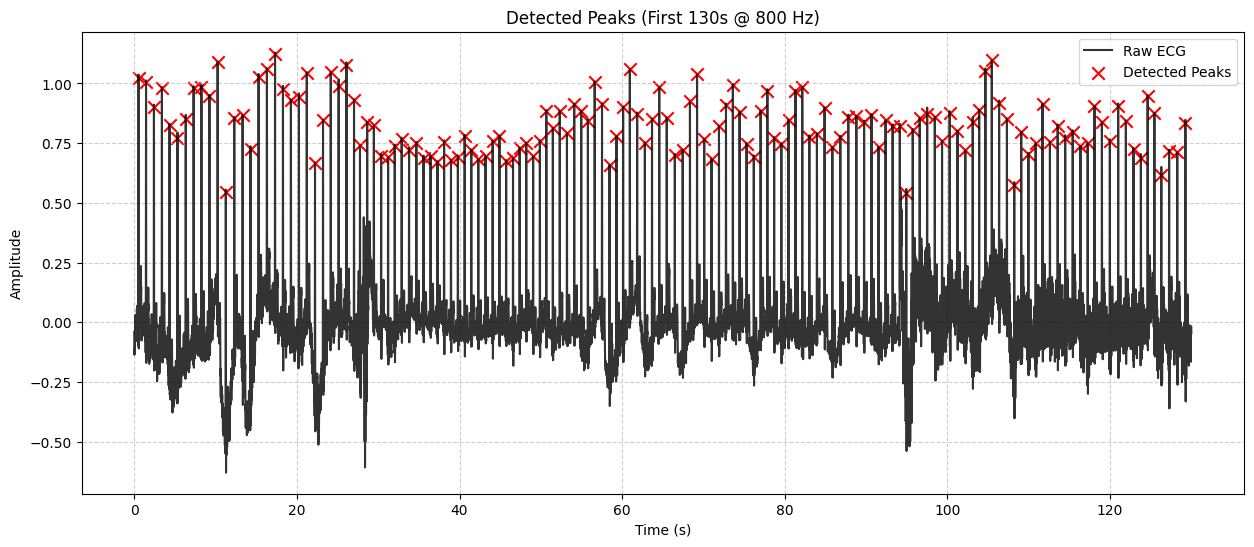

Visualization complete for first 130 seconds at 800 Hz (n=104000).


In [54]:
duration_sec = 130
n = min(int(duration_sec * sample_rate), len(lab3_Results))

# 3) Build time and signal slices
time_segment = np.arange(n) / sample_rate
signal_segment = lab3_Results[:n]

# 4) Filter detected indices to the displayed window
if 'detected_indices' in globals() and detected_indices is not None:
    filtered_detections = detected_indices[(detected_indices >= 0) & (detected_indices < n)]
else:
    filtered_detections = np.array([], dtype=int)

# 5) Plot
plt.figure(figsize=(15, 6))
plt.plot(time_segment, signal_segment, label='Raw ECG', color='black', alpha=0.8)

# Overlay detected complexes with red markers if any
if filtered_detections.size > 0:
    plt.scatter(time_segment[filtered_detections], signal_segment[filtered_detections],
                color='red', marker='x', s=80, label='Detected Peaks')

# Decorate
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Detected Peaks (First {duration_sec}s @ {sample_rate} Hz)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f'Visualization complete for first {duration_sec} seconds at {sample_rate} Hz (n={n}).')